In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Verify GPU availability for RTX 3050
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

# Visualization styling
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline
pd.set_option('display.max_columns', None)

Num GPUs Available:  1


In [2]:
# Load the dataset
df = pd.read_csv('../datasets/churn-bigml-80.csv')

# Separate features and target
X_raw = df.drop(columns=['Churn'])
y = df['Churn'].astype(int) 

# One-Hot Encoding for categorical text
X_encoded = pd.get_dummies(X_raw, drop_first=True)

# Train-Test Split (Stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

# Feature Scaling: Neural networks require ALL features to be strictly scaled.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame to visualize the scaled inputs
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_encoded.columns)
print(f"Training Data Shape: {X_train_scaled.shape}")
display(X_train_scaled_df.head())

Training Data Shape: (2132, 68)


,Account length,Area code,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,State_AL,State_AR,State_AZ,State_CA,State_CO,State_CT,State_DC,State_DE,State_FL,State_GA,State_HI,State_IA,State_ID,State_IL,State_IN,State_KS,State_KY,State_LA,State_MA,State_MD,State_ME,State_MI,State_MN,State_MO,State_MS,State_MT,State_NC,State_ND,State_NE,State_NH,State_NJ,State_NM,State_NV,State_NY,State_OH,State_OK,State_OR,State_PA,State_RI,State_SC,State_SD,State_TN,State_TX,State_UT,State_VA,State_VT,State_WA,State_WI,State_WV,State_WY,International plan_Yes,Voice mail plan_Yes
0,0.033303,-0.521107,-0.583143,1.688380,-1.009029,1.688657,-0.562170,1.639851,-0.562232,-0.624170,0.238208,-0.625944,0.025481,0.214388,0.023443,-0.434702,-0.164241,-0.132895,-0.127302,-0.089654,-0.151765,-0.153375,-0.132895,-0.136505,-0.141759,-0.140028,-0.131056,-0.125386,-0.140028,-0.132895,-0.143471,-0.132895,-0.131056,-0.11536,-0.143471,7.231874,-0.145165,-0.148498,-0.162728,-0.131056,-0.138277,-0.150140,-0.145165,-0.12147,-0.127302,-0.132895,-0.145165,-0.138277,-0.153375,-0.164241,-0.158114,-0.132895,-0.154969,-0.113255,-0.141759,-0.143471,-0.134711,-0.12147,-0.143471,-0.151765,-0.162728,-0.145165,-0.138277,-0.153375,-0.186953,-0.158114,-0.331419,-0.607701
1,1.423013,-0.686677,-0.583143,1.118432,-1.655453,1.117947,-0.932862,-0.111558,-0.931779,0.946827,-1.466883,0.948981,-0.010096,0.623954,-0.016088,0.326830,-0.164241,-0.132895,-0.127302,-0.089654,-0.151765,-0.153375,-0.132895,-0.136505,-0.141759,-0.140028,-0.131056,-0.125386,-0.140028,-0.132895,-0.143471,-0.132895,-0.131056,-0.11536,-0.143471,-0.138277,-0.145165,-0.148498,-0.162728,-0.131056,-0.138277,6.660458,-0.145165,-0.12147,-0.127302,-0.132895,-0.145165,-0.138277,-0.153375,-0.164241,-0.158114,-0.132895,-0.154969,-0.113255,-0.141759,-0.143471,-0.134711,-0.12147,-0.143471,-0.151765,-0.162728,-0.145165,-0.138277,-0.153375,-0.186953,-0.158114,-0.331419,-0.607701
2,-0.547849,-0.521107,-0.583143,-0.655970,-0.511780,-0.656028,-1.268436,-0.461840,-1.269191,0.226294,1.478274,0.227140,0.986060,-0.195178,0.985352,-0.434702,-0.164241,-0.132895,-0.127302,-0.089654,-0.151765,-0.153375,-0.132895,-0.136505,-0.141759,-0.140028,-0.131056,-0.125386,-0.140028,-0.132895,-0.143471,-0.132895,-0.131056,-0.11536,-0.143471,-0.138277,-0.145165,-0.148498,-0.162728,-0.131056,-0.138277,-0.150140,-0.145165,-0.12147,-0.127302,-0.132895,-0.145165,-0.138277,-0.153375,-0.164241,-0.158114,-0.132895,-0.154969,-0.113255,-0.141759,-0.143471,-0.134711,-0.12147,6.970036,-0.151765,-0.162728,-0.145165,-0.138277,-0.153375,-0.186953,-0.158114,-0.331419,-0.607701
3,0.791327,-0.686677,-0.583143,-0.178246,0.333544,-0.178628,0.167508,1.039368,0.167680,0.102268,-1.105197,0.100271,0.452405,-1.014310,0.458278,-0.434702,-0.164241,-0.132895,-0.127302,-0.089654,-0.151765,-0.153375,-0.132895,-0.136505,-0.141759,-0.140028,-0.131056,-0.125386,-0.140028,-0.132895,-0.143471,-0.132895,-0.131056,-0.11536,-0.143471,-0.138277,-0.145165,-0.148498,-0.162728,-0.131056,-0.138277,-0.150140,-0.145165,-0.12147,-0.127302,-0.132895,-0.145165,7.231874,-0.153375,-0.164241,-0.158114,-0.132895,-0.154969,-0.113255,-0.141759,-0.143471,-0.134711,-0.12147,-0.143471,-0.151765,-0.162728,-0.145165,-0.138277,-0.153375,-0.186953,-0.158114,-0.331419,-0.607701
4,-0.143569,-0.686677,-0.583143,1.079698,-1.754903,1.079972,-0.265617,-0.111558,-0.266136,-0.214687,0.754902,-0.214714,0.559136,-0.195178,0.563693,1.849893,-0.164241,-0.132895,7.855309,-0.089654,-0.151765,-0.153375,-0.132895,-0.136505,-0.141759,-0.140028,-0.131056,-0.125386,-0.140028,-0.132895,-0.143471,-0.132895,-0.131056,-0.11536,-0.143471,-0.138277,-0.145165,-0.148498,-0.162728,-0.131056,-0.138277,-0.150140,-0.145165,-0.12147,-0.127302,-0.132895,-0.145165,-0.138277,-0.153375,-0.164241,-0.158114,-0.132895,-0.154969,-0.113255,-0.1417

In [3]:
# Initialize the Sequential model
model = Sequential()

# First Hidden Layer with 64 neurons and ReLU activation
model.add(Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)))
model.add(Dropout(0.3)) # Drop 30% of connections to prevent overfitting

# Second Hidden Layer with 32 neurons
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.2)) # Drop 20% of connections

# Output Layer for Binary Classification (1 neuron, Sigmoid)
model.add(Dense(1, activation='sigmoid'))

# Compile the model
# Adam optimizer dynamically adjusts the learning rate.
# BinaryCrossentropy is the mathematically correct loss function for Yes/No targets.
model.compile(
    optimizer='adam', 
    loss='binary_crossentropy', 
    metrics=['accuracy']
)

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                4416      
                                                                 
 dropout (Dropout)           (None, 64)                0         
                                                                 
 dense_1 (Dense)             (None, 32)                2080      
                                                                 
 dropout_1 (Dropout)         (None, 32)                0         
                                                                 
 dense_2 (Dense)             (None, 1)                 33        
                                                                 
Total params: 6,529
Trainable params: 6,529
Non-trainable params: 0
_________________________________________________________________


In [4]:
# Early stopping monitors the validation loss and stops training if it degrades for 10 epochs
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the network, reserving 20% of the training data purely for internal validation
history = model.fit(
    X_train_scaled, 
    y_train, 
    epochs=100, 
    batch_size=32, 
    validation_split=0.2, 
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
54/54 [==============================] - 1s 5ms/step - loss: 0.4499 - accuracy: 0.8375 - val_loss: 0.4292 - val_accuracy: 0.8337
Epoch 2/100
54/54 [==============================] - 0s 3ms/step - loss: 0.3930 - accuracy: 0.8592 - val_loss: 0.3986 - val_accuracy: 0.8361
Epoch 3/100
54/54 [==============================] - 0s 3ms/step - loss: 0.3732 - accuracy: 0.8610 - val_loss: 0.3843 - val_accuracy: 0.8407
Epoch 4/100
54/54 [==============================] - 0s 3ms/step - loss: 0.3395 - accuracy: 0.8692 - val_loss: 0.3747 - val_accuracy: 0.8478
Epoch 5/100
54/54 [==============================] - 0s 3ms/step - loss: 0.3305 - accuracy: 0.8674 - val_loss: 0.3703 - val_accuracy: 0.8454
Epoch 6/100
54/54 [==============================] - 0s 3ms/step - loss: 0.3233 - accuracy: 0.8669 - val_loss: 0.3667 - val_accuracy: 0.8431
Epoch 7/100
54/54 [==============================] - 0s 3ms/step - loss: 0.3042 - accuracy: 0.8751 - val_loss: 0.3601 - val_accuracy: 0.8314
Epoch 8/100
5


--- Final Unseen Test Set Performance ---
Test Accuracy: 0.8596
Test Loss: 0.4187



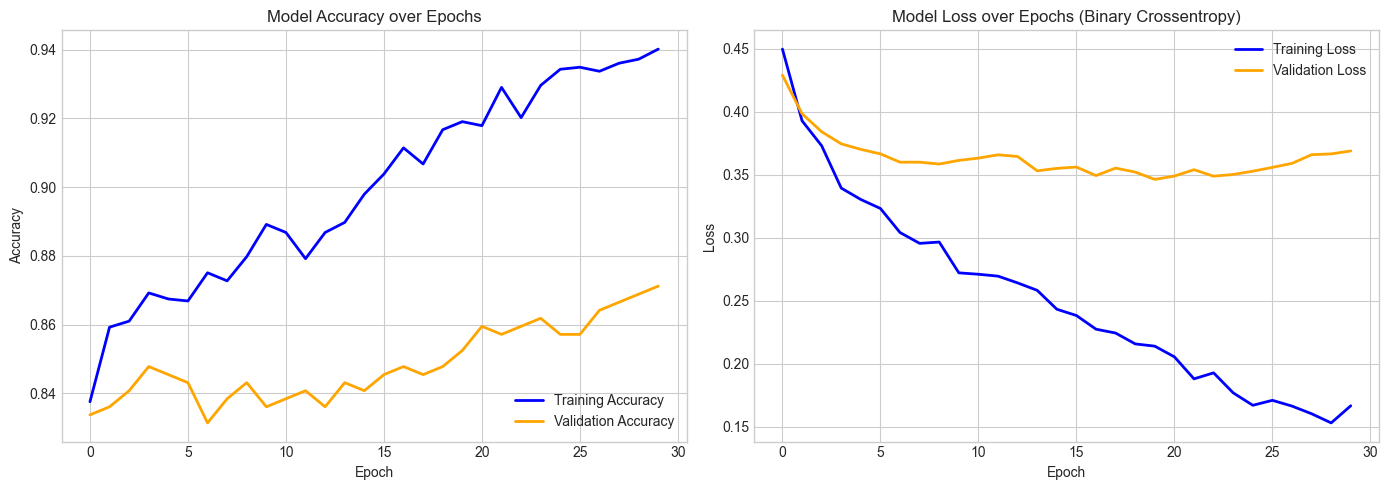

In [5]:
# Evaluate final performance on the completely unseen test set
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"\n--- Final Unseen Test Set Performance ---")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}\n")

# Create a 1x2 grid for plotting
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Accuracy Curve
ax[0].plot(history.history['accuracy'], label='Training Accuracy', color='blue', linewidth=2)
ax[0].plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange', linewidth=2)
ax[0].set_title('Model Accuracy over Epochs')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Accuracy')
ax[0].legend(loc='lower right')

# Plot 2: Loss Curve
ax[1].plot(history.history['loss'], label='Training Loss', color='blue', linewidth=2)
ax[1].plot(history.history['val_loss'], label='Validation Loss', color='orange', linewidth=2)
ax[1].set_title('Model Loss over Epochs (Binary Crossentropy)')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Loss')
ax[1].legend(loc='upper right')

plt.tight_layout()
plt.show()